In [19]:
import sys
import os

# Aggiunge la cartella 'src' al percorso dei moduli
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../src')))
import numpy as np
import matplotlib.pyplot as plt
from models.black_scholes import BlackScholes

In [20]:
S0 = 100      # initial price
r = 0.05      # risk-free rate
sigma = 0.2   # volatility
T = 1         # 1 year
K = 100       # strike
n_paths = 50000  # paths number for Monte Carlo

In [21]:
bs = BlackScholes(S0, r, sigma)
ST = bs.simulate(T, n_paths)

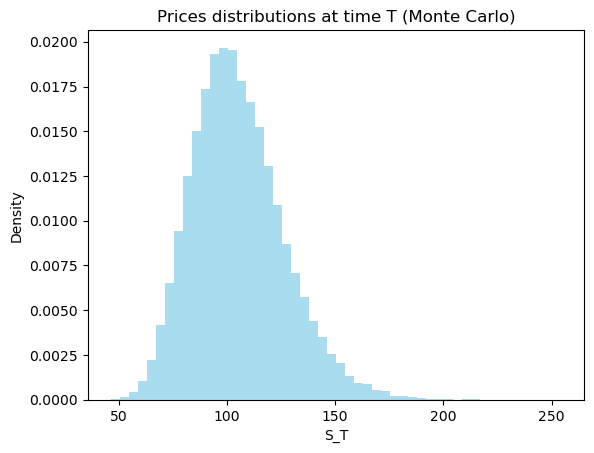

In [22]:
plt.hist(ST, bins=50, density=True, alpha=0.7, color='skyblue')
plt.title("Prices distributions at time T (Monte Carlo)")
plt.xlabel("S_T")
plt.ylabel("Density")
plt.show()

In [23]:
price_mc = bs.call_price_mc(K, T, n_paths)
price_cf = bs.call_price_closed_form(K, T)

print(f"Call price Monte Carlo: {price_mc:.4f}")
print(f"Call price closed-form formula: {price_cf:.4f}")

Call price Monte Carlo: 10.4680
Call price closed-form formula: 10.4506


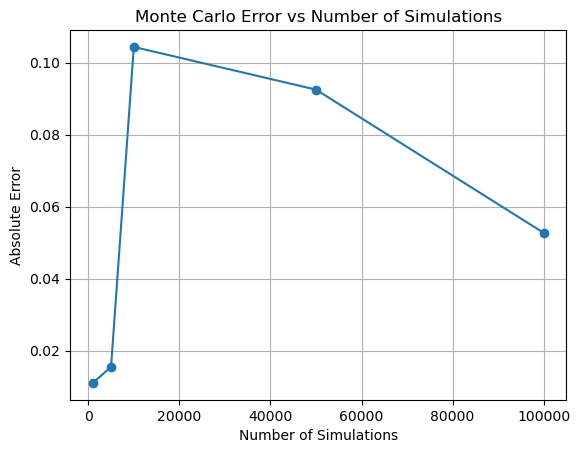

In [24]:
n_samples = [1000, 5000, 10000, 50000, 100000]
errors = []

for n in n_samples:
    price = bs.call_price_mc(K, T, n)
    errors.append(abs(price - price_cf))

plt.plot(n_samples, errors, marker='o')
plt.title("Monte Carlo Error vs Number of Simulations")
plt.xlabel("Number of Simulations")
plt.ylabel("Absolute Error")
plt.grid(True)
plt.show()